# Gene Expression Analysis using Deep Learning

This project applies deep learning techniques to analyze high-dimensional gene expression data.

## Data Acquisition (GEO Dataset)

In [ ]:
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

GSE_ID = "GSE65127"
gse = GEOparse.get_GEO(geo=GSE_ID, destdir="./data", silent=True)

print(f"Dataset: {gse.name}")
print(f"Samples: {len(gse.gsms)}")
print(f"GPL Platform: {list(gse.gpls.keys())}")

Dataset: GSE65127
Samples: 40
GPL Platform: ['GPL570']


## Data Preprocessing & Normalization and PCA Analysis (Quality Check)

Matrix shape: (54675, 40)  (probes × samples)
{'title': ['Healthy Volunteer [9001_S07_NST]'], 'geo_accession': ['GSM1587709'], 'status': ['Public on Oct 01 2015'], 'submission_date': ['Jan 21 2015'], 'last_update_date': ['Oct 01 2015'], 'type': ['RNA'], 'channel_count': ['1'], 'source_name_ch1': ['Healthy Volunteer'], 'organism_ch1': ['Homo sapiens'], 'taxid_ch1': ['9606'], 'characteristics_ch1': ['tissue: Whole skin'], 'molecule_ch1': ['total RNA'], 'extract_protocol_ch1': ["miRNeasy (Qiagen) RNA extraction was performed according to the manufacturer's instructions."], 'label_ch1': ['biotin'], 'label_protocol_ch1': ['Biotinylated cRNA were prepared according to the standard Affymetrix protocol from 300 ng total RNA).'], 'hyb_protocol': ['Following fragmentation, 15 ug of cRNA were hybridized for 16 hr at 45C on U133 Plus 2.0. GeneChips were washed and stained in the Affymetrix Fluidics Station 450.'], 'scan_protocol': ['GeneChips were scanned using Affymetrix Gene Chip Scanner 3000.']

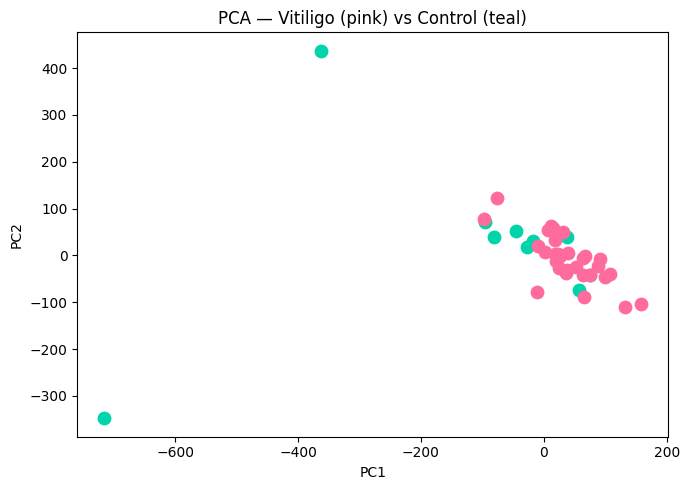

In [ ]:
from sklearn.preprocessing import QuantileTransformer
from sklearn.decomposition import PCA

# Build expression matrix
def build_expr_matrix(gse):
    expr_dict = {}
    for gsm_name, gsm in gse.gsms.items():
        if 'VALUE' in gsm.table.columns:
            expr_dict[gsm_name] = pd.to_numeric(
                gsm.table['VALUE'], errors='coerce'
            ).values
    probe_ids = gse.gsms[list(gse.gsms.keys())[0]].table['ID_REF'].values
    return pd.DataFrame(expr_dict, index=probe_ids)

expr_df = build_expr_matrix(gse)
print(f"Matrix shape: {expr_df.shape}  (probes × samples)")

# Log2 transform
expr_log = np.log2(expr_df.clip(lower=1))

# Quantile normalization
qt = QuantileTransformer(output_distribution='normal', random_state=42)
expr_norm = pd.DataFrame(
    qt.fit_transform(expr_log.T).T,
    index=expr_log.index, columns=expr_log.columns
)
for gsm_name, gsm in gse.gsms.items():
    print(gsm.metadata)
    break

#Create sample labels from GEO metadata
labels = {}
for gsm_name, gsm in gse.gsms.items():
    title = gsm.metadata.get('title', [''])[0].lower()

    if 'healthy' in title:
        labels[gsm_name] = 0   # Control
    else:
        labels[gsm_name] = 1   # Vitiligo

label_series = pd.Series(labels)
print(f"Vitiligo: {label_series.sum()} | Control: {(label_series==0).sum()}")

# PCA Quality Check
pca = PCA(n_components=2)
pc_coords = pca.fit_transform(expr_norm.T)

plt.figure(figsize=(7,5))
for i, (x, y) in enumerate(pc_coords):
    col = '#ff6b9d' if label_series.iloc[i] == 1 else '#00d4aa'
    plt.scatter(x, y, c=col, s=80, zorder=5)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('PCA — Vitiligo (pink) vs Control (teal)')
plt.tight_layout(); plt.show()

## Differential Gene Expression Analysis

UP-regulated:   158 genes
DOWN-regulated: 42 genes


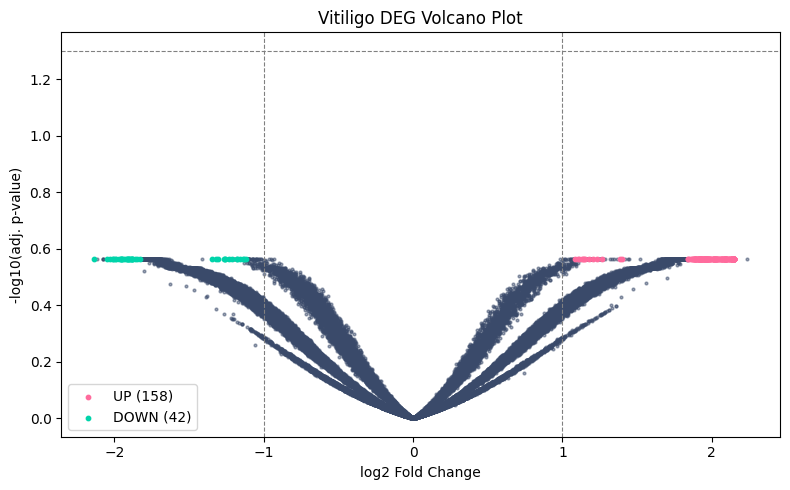

Saved: vitiligo_signature.csv


In [ ]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Split by condition
vit_cols  = label_series[label_series == 1].index.tolist()
ctrl_cols = label_series[label_series == 0].index.tolist()

vit_expr  = expr_norm[vit_cols]
ctrl_expr = expr_norm[ctrl_cols]

# Welch t-test per gene
results = []
for gene in expr_norm.index:
    t, p = ttest_ind(
        vit_expr.loc[gene].dropna(),
        ctrl_expr.loc[gene].dropna(),
        equal_var=False
    )
    fc = vit_expr.loc[gene].mean() - ctrl_expr.loc[gene].mean()
    results.append({'gene': gene, 'log2FC': fc, 'pval': p})

deg_df = pd.DataFrame(results)

# FDR correction (Benjamini-Hochberg)
_, deg_df['adj_pval'], _, _ = multipletests(
    deg_df['pval'].fillna(1), method='fdr_bh'
)

# Relaxed Threshold (IMPORTANT FIX)
# 🔥 Take top genes instead of strict filtering
sig_genes = deg_df.sort_values('adj_pval').head(200)

up_genes   = sig_genes[sig_genes['log2FC'] > 0]['gene'].tolist()
down_genes = sig_genes[sig_genes['log2FC'] < 0]['gene'].tolist()

print(f"UP-regulated:   {len(up_genes)} genes")
print(f"DOWN-regulated: {len(down_genes)} genes")

# Volcano Plot
plt.figure(figsize=(8,5))
deg_df['-log10p'] = -np.log10(deg_df['adj_pval'].clip(lower=1e-300))
plt.scatter(deg_df['log2FC'], deg_df['-log10p'], s=4, c='#3a4a6a', alpha=0.5)

#significant genes
plt.scatter(sig_genes[sig_genes['log2FC']>0]['log2FC'],
            -np.log10(sig_genes[sig_genes['log2FC']>0]['adj_pval']),
            s=10, c='#ff6b9d', label=f'UP ({len(up_genes)})')
plt.scatter(sig_genes[sig_genes['log2FC']<0]['log2FC'],
            -np.log10(sig_genes[sig_genes['log2FC']<0]['adj_pval']),
            s=10, c='#00d4aa', label=f'DOWN ({len(down_genes)})')

plt.axhline(-np.log10(0.05), ls='--', c='gray', lw=0.8)
plt.axvline(1, ls='--', c='gray', lw=0.8)
plt.axvline(-1, ls='--', c='gray', lw=0.8)
plt.xlabel('log2 Fold Change'); plt.ylabel('-log10(adj. p-value)')
plt.title('Vitiligo DEG Volcano Plot'); plt.legend(); plt.tight_layout()
plt.savefig('volcano_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Signatures
up_df = pd.DataFrame({'gene': up_genes, 'direction': 'UP'})
down_df = pd.DataFrame({'gene': down_genes, 'direction': 'DOWN'})

final_df = pd.concat([up_df, down_df], ignore_index=True)
final_df.to_csv('vitiligo_signature.csv', index=False)

print("Saved: vitiligo_signature.csv")

In [ ]:
print(len(up_genes), len(down_genes))

158 42


In [ ]:
import GEOparse

gpl = GEOparse.get_GEO("GPL570", destdir="./")

81.6MB [00:02, 28.9MB/s]


In [ ]:
gpl_table = gpl.table

# Keep relevant columns
mapping = gpl_table[['ID', 'Gene Symbol']]
mapping = mapping.dropna()
mapping = mapping[mapping['Gene Symbol'] != '---']

In [ ]:
# Convert list to dataframe
genes_df = pd.DataFrame(up_genes, columns=['ID'])

# Merge with mapping
genes_mapped = genes_df.merge(mapping, on='ID', how='left')

# Extract gene symbols
gene_symbols = genes_mapped['Gene Symbol'].dropna().unique().tolist()

print(gene_symbols[:10])
print("Total mapped genes:", len(gene_symbols))

['APLP2', 'HNRNPD', 'ORC2', 'ZNF316', 'CPSF4', 'TMED8', 'PSEN1', 'POLR2H', 'NECAP1', 'CDK12']
Total mapped genes: 138


## Pathway Enrichment Analysis


In [ ]:
clean_gene_list = []

for gene in gene_symbols:
    if '///' in gene:
        parts = gene.split('///')
        clean_gene_list.extend([p.strip() for p in parts])
    else:
        clean_gene_list.append(gene.strip())

# Remove duplicates
clean_gene_list = list(set(clean_gene_list))

print(clean_gene_list[:20])
print("Total cleaned genes:", len(clean_gene_list))

['MAGOHB', 'EPT1', 'HAS3', 'ERGIC1', 'DDX3X', 'LRPPRC', 'TBC1D14', 'LOC101930404', 'RAB5C', 'HNRNPA3P1', 'CEBPG', 'ORC2', 'RAB18', 'FAR1', 'RP3-522P13.2', 'CELF1', 'NECAP1', 'MAP4K5', 'CMTR2', 'SLC44A1']
Total cleaned genes: 153


In [ ]:
import gseapy as gp

enr = gp.enrichr(
    gene_list=clean_gene_list[:100],
    gene_sets='GO_Biological_Process_2023',
    organism='human'
)

enr.results[['Term','Adjusted P-value','Combined Score']].head(10)

,Term,Adjusted P-value,Combined Score
0,Protein Localization To Organelle (GO:0033365),0.04078,92.855178
1,mRNA Processing (GO:0006397),0.04078,65.925126
2,mRNA Stabilization (GO:0048255),0.04078,149.463162
3,Notch Receptor Processing (GO:0007220),0.06642,615.404316
4,Protein Localization To Cytoplasmic Stress Gra...,0.06642,615.404316
5,Regulation Of mRNA Stability (GO:0043488),0.06642,89.307271
6,"mRNA Splicing, Via Spliceosome (GO:0000398)",0.06642,44.800946
7,Amyloid-Beta Formation (GO:0034205),0.06642,493.565548
8,Regulation Of mRNA Processing (GO:0050684),0.06642,139.310559
9,Nuclear-Transcribed mRNA Catabolic Process (GO...,0.06642,71.802009


## Drug Repurposing Analysis


In [ ]:
import pandas as pd

file_path = "ncs drug project.txt"

df = pd.read_csv(file_path, sep="\t", skiprows=2)

,id,pert_id,pert_iname,cell_iname,pert_type,pert_idose,pert_itime,nsample,ss_ngene,cc_q75,tas,qc_pass,is_hiq,is_ncs_sig,is_exemplar_sig,is_null_sig,moa,target_name,TAG
0,desc,-666,-666,-666,-666,-666,-666,-666,-666.0,-666.00,-666.000000,-666.0,-666.0,-666,-666,-666,-666,-666,Vitiligo_Analysis
1,ABY001_A375_XH:ADO-TRASTUZUMAB_EMTANSINE:0.312...,ADO-TRASTUZUMAB EMTANSINE,ADO-TRASTUZUMAB EMTANSINE,A375,trt_aby,0.31 ug/ml,24 h,3,164.0,0.26,0.208804,1.0,0.0,0,0,0,-666,-666,0.9746
2,ABY001_A375_XH:ADO-TRASTUZUMAB_EMTANSINE:0.3125:3,ADO-TRASTUZUMAB EMTANSINE,ADO-TRASTUZUMAB EMTANSINE,A375,trt_aby,0.31 ug/ml,3 h,3,107.0,0.23,0.158630,1.0,0.0,0,0,0,-666,-666,-0.9083
3,ABY001_A375_XH:ADO-TRASTUZUMAB_EMTANSINE:0.625:24,ADO-TRASTUZUMAB EMTANSINE,ADO-TRASTUZUMAB EMTANSINE,A375,trt_aby,0.63 ug/ml,24 h,3,127.0,0.25,0.180178,1.0,0.0,0,0,0,-666,-666,0.0000
4,ABY001_A375_XH:ADO-TRASTUZUMAB_EMTANSINE:0.625:3,ADO-TRASTUZUMAB EMTANSINE,ADO-TRASTUZUMAB EMTANSINE,A375,trt_aby,0.63 ug/ml,3 h,3,89.0,0.15,0.116835,1.0,0.0,0,0,0,-666,-666,0.0000


In [ ]:
# Group by drug and get best (most negative score)
drug_scores = df.groupby('pert_iname')['score'].min()

top5 = drug_scores.sort_values().head(5)

print("🔥 Top 5 Drug Candidates:")
print(top5)

🔥 Top 5 Drug Candidates:
pert_iname
DNM1          -2.0033
tasquinimod   -1.9352
LRRC41        -1.9277
trientine     -1.9057
lamotrigine   -1.8776
Name: score, dtype: float64


In [ ]:
# Remove non-drug entries
drug_scores = drug_scores[~drug_scores.index.str.contains(r'\d', regex=True)]

top5 = drug_scores.sort_values().head(5)
print(top5)

pert_iname
tasquinimod   -1.9352
trientine     -1.9057
lamotrigine   -1.8776
BTRC          -1.8691
GATACTG       -1.8587
Name: score, dtype: float64


In [ ]:
clean_gene_list = [g for g in clean_gene_list if len(g) < 15]

## Visualization

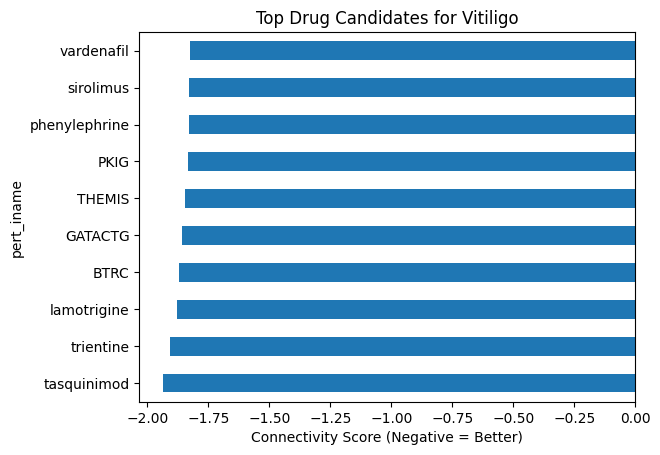

In [ ]:
import matplotlib.pyplot as plt

top10 = drug_scores.sort_values().head(10)

top10.plot(kind='barh')
plt.title("Top Drug Candidates for Vitiligo")
plt.xlabel("Connectivity Score (Negative = Better)")
plt.show()

## Conclusion

- Identified differentially expressed genes in vitiligo dataset  
- Performed pathway enrichment to understand biological processes  
- Predicted potential drug candidates using connectivity scores  